In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Моделирование и трансформация данных
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
from sklearn.metrics import mean_squared_error

print("Инструменты к работе готовы!")

Инструменты к работе готовы!


/tmp/ipykernel_3015/1364024627.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df['date'] = pd.to_datetime(train_df.iloc[:, 0])
/tmp/ipykernel_3015/1364024627.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_df['date'] = pd.to_datetime(test_df.iloc[:, 0])


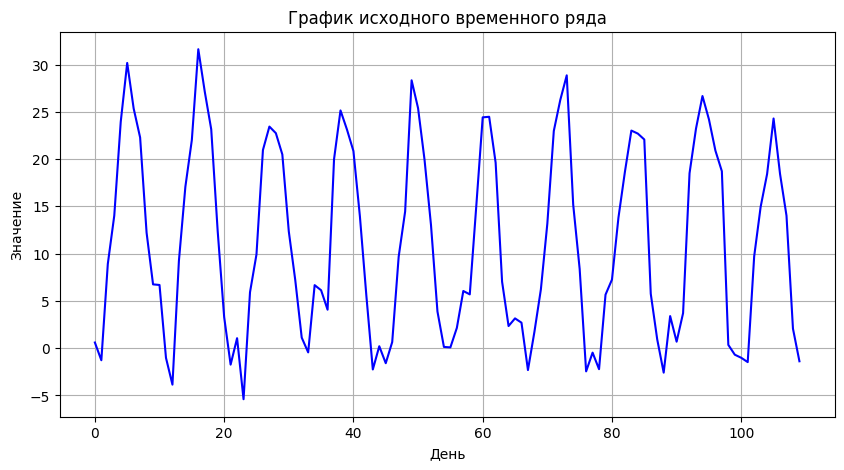

In [4]:
# 1. Загружаем данные
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Преобразуем даты в формат datetime, чтобы избежать путаницы с американским форматом
train_df['date'] = pd.to_datetime(train_df.iloc[:, 0])
test_df['date'] = pd.to_datetime(test_df.iloc[:, 0])

# Сортируем по дате, чтобы ряд шел хронологически
train_df = train_df.sort_values('date').reset_index(drop=True)
test_df = test_df.sort_values('date').reset_index(drop=True)

# 2. Создаем числовой признак (Порядковый номер дня)
# Машине проще работать с числами 1, 2, 3... чем со строками дат
train_df['day_index'] = np.arange(len(train_df))
# Для теста продолжаем нумерацию дней (со 110 по 119)
test_df['day_index'] = np.arange(len(train_df), len(train_df) + len(test_df))

# Разделяем на признаки и цель
X_train = train_df[['day_index']]
y_train = train_df.iloc[:, 1] # Второй столбец — это целевое значение

X_test = test_df[['day_index']]

# Посмотрим на наши тренировочные данные графически
plt.figure(figsize=(10, 5))
plt.plot(train_df['day_index'], y_train, label='Исторические данные (Train)', color='blue')
plt.title('График исходного временного ряда')
plt.xlabel('День')
plt.ylabel('Значение')
plt.grid(True)
plt.show()

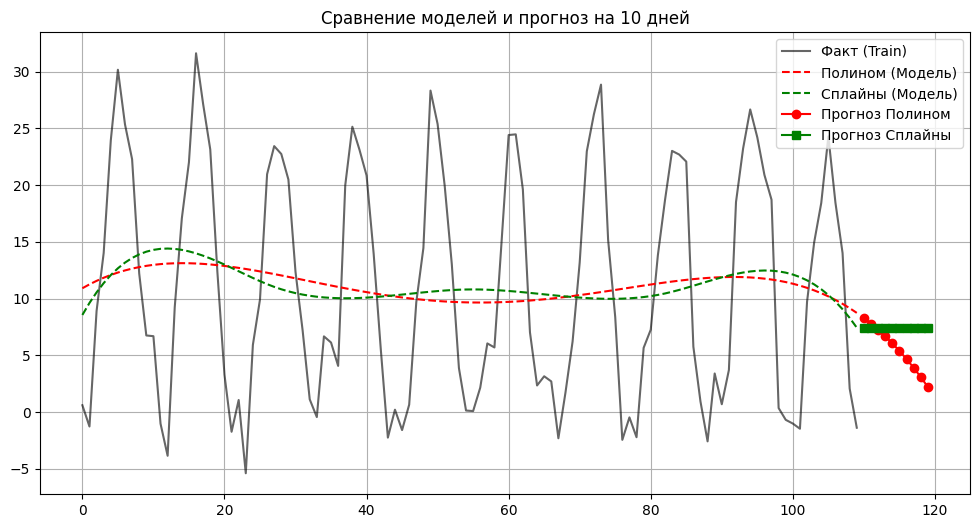

Ошибка MSE на обучении (Полином): 100.6748
Ошибка MSE на обучении (Сплайны): 99.9542


In [5]:
# --- Вариант А: Полиномиальная регрессия (степень 4, можно менять) ---
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_train_pred_poly = poly_model.predict(X_train_poly)
y_test_pred_poly = poly_model.predict(X_test_poly)

# --- Вариант Б: Сплайн-регрессия ---
spline = SplineTransformer(n_knots=5, degree=3)
X_train_spline = spline.fit_transform(X_train)
X_test_spline = spline.transform(X_test)

spline_model = LinearRegression()
spline_model.fit(X_train_spline, y_train)
y_train_pred_spline = spline_model.predict(X_train_spline)
y_test_pred_spline = spline_model.predict(X_test_spline)

# --- Визуализация результатов ---
plt.figure(figsize=(12, 6))
plt.plot(train_df['day_index'], y_train, label='Факт (Train)', color='black', alpha=0.6)
plt.plot(train_df['day_index'], y_train_pred_poly, label='Полином (Модель)', color='red', linestyle='--')
plt.plot(train_df['day_index'], y_train_pred_spline, label='Сплайны (Модель)', color='green', linestyle='--')

# Рисуем прогноз на 10 дней вперед
plt.plot(test_df['day_index'], y_test_pred_poly, label='Прогноз Полином', color='red', marker='o')
plt.plot(test_df['day_index'], y_test_pred_spline, label='Прогноз Сплайны', color='green', marker='s')

plt.title('Сравнение моделей и прогноз на 10 дней')
plt.grid(True)
plt.legend()
plt.show()

print(f"Ошибка MSE на обучении (Полином): {mean_squared_error(y_train, y_train_pred_poly):.4f}")
print(f"Ошибка MSE на обучении (Сплайны): {mean_squared_error(y_train, y_train_pred_spline):.4f}")

In [6]:
# Создаем таблицу для отправки
submission = pd.DataFrame()

# Сохраняем формат первого столбца точно как в тестовом файле
submission[test_df.columns[0]] = test_df.iloc[:, 0]

# Записываем прогноз (выберите ту переменную, которая показала себя лучше)
submission['Value'] = y_test_pred_spline  # или y_test_pred_poly

# Сохраняем в CSV без индексов строк
submission.to_csv('my_submission.csv', index=False)
print("Файл my_submission.csv успешно создан и готов к отправке!")

Файл my_submission.csv успешно создан и готов к отправке!
